# CSE 153 Assignment 2 Notebook

1. Data processing: inspect the raw audio and rebuild the fixed-length 32 kHz dataset.
2. Augmentation: create background-noise, pitch-shift, and speed-up variants.
3. Visualization: generate quick checks like spectrograms and pitch histograms.

In [2]:
from pathlib import Path
import sys

import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.append(str(Path("src")))

from librosa_audio_utils import configure_logging, duration_samples, find_audio_files, fix_length, load_audio, write_audio
from rebuild_audio_librosa import (
    add_background_noise,
    build_augmentations,
    build_processed_outputs,
    collect_sources,
    compute_target_length,
    pitch_shift_audio,
    time_stretch_audio,
)

## 1. Data Processing

We start from the raw flat WAV files and Dropbox MP3 files, then normalize everything to mono at 32 kHz and a shared integer-second length.

In [3]:
sample_rate = 32000
flat_files, dropbox_files = collect_sources(Path("data/raw/flat"), Path("data/raw/dropbox"))
target_length = compute_target_length(flat_files, dropbox_files, sample_rate)

print(f"flat files: {len(flat_files)}")
print(f"dropbox files: {len(dropbox_files)}")
print(f"target length: {target_length} samples ({target_length / sample_rate:.0f} s)")

# Actual processing step used in the project:
# flat_audio, dropbox_audio = build_processed_outputs(
#     flat_files=flat_files,
#     dropbox_files=dropbox_files,
#     audio_root=Path("data/audio"),
#     sample_rate=sample_rate,
#     target_length=target_length,
# )

raw_summary = pd.DataFrame(
    [
        {"group": "flat", "files": len(flat_files)},
        {"group": "dropbox", "files": len(dropbox_files)},
    ]
)
raw_summary

c:\Users\phill\OneDrive\Desktop\CSE 153 Work\CSE153-SP26-Assignment2\.venv-basic-pitch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flat files: 65
dropbox files: 148
target length: 896000 samples (28 s)


,group,files
0,flat,65
1,dropbox,148


## 2. Augmentation

We used three augmentations to expand the dataset: background noise, pitch shift, and speed up.

In [4]:
audio_path = Path("data/raw/flat/001.wav")
audio = load_audio(audio_path, sample_rate)

# Actual augmentation functions used in the project.
# They match src/rebuild_audio_librosa.py.

def add_background_noise(audio: np.ndarray, noise_db: float, seed: int) -> np.ndarray:
    rng = np.random.default_rng(seed)
    noise = rng.standard_normal(len(audio)).astype(np.float32)
    signal_rms = float(np.sqrt(np.mean(audio**2))) if len(audio) else 0.0
    signal_rms = max(signal_rms, 1e-4)
    noise_rms = signal_rms * (10.0 ** (noise_db / 20.0))
    noise = noise / max(float(np.sqrt(np.mean(noise**2))), 1e-8) * noise_rms
    mixed = audio + noise
    return np.clip(mixed, -1.0, 1.0).astype(np.float32)


def pitch_shift_audio(audio: np.ndarray, sample_rate: int, semitones: float) -> np.ndarray:
    shifted = librosa.effects.pitch_shift(audio, sr=sample_rate, n_steps=semitones)
    return shifted.astype(np.float32, copy=False)


def time_stretch_audio(audio: np.ndarray, rate: float) -> np.ndarray:
    stretched = librosa.effects.time_stretch(audio, rate=rate)
    return stretched.astype(np.float32, copy=False)


noisy = fix_length(add_background_noise(audio, noise_db=-24.0, seed=1), target_length)
shifted = fix_length(pitch_shift_audio(audio, sample_rate, semitones=2.0), target_length)
sped_up = fix_length(time_stretch_audio(audio, rate=1.25), target_length)

print(f"original samples: {len(audio)}")
print(f"noise samples: {len(noisy)}")
print(f"pitch shift samples: {len(shifted)}")
print(f"speed up samples: {len(sped_up)}")

# Actual rebuild call used in the project:
# build_augmentations(
#     audio_sets={"flat": flat_audio, "dropbox": dropbox_audio},
#     audio_root=Path("data/audio"),
#     sample_rate=sample_rate,
#     target_length=target_length,
#     pitch_semitones=2.0,
#     speed_up_rate=1.25,
#     noise_db=-24.0,
# )

original samples: 239360
noise samples: 896000
pitch shift samples: 896000
speed up samples: 896000


## 3. Quick Visual Check

A small spectrogram comparison is enough to confirm the processing and augmentation steps are behaving as expected.

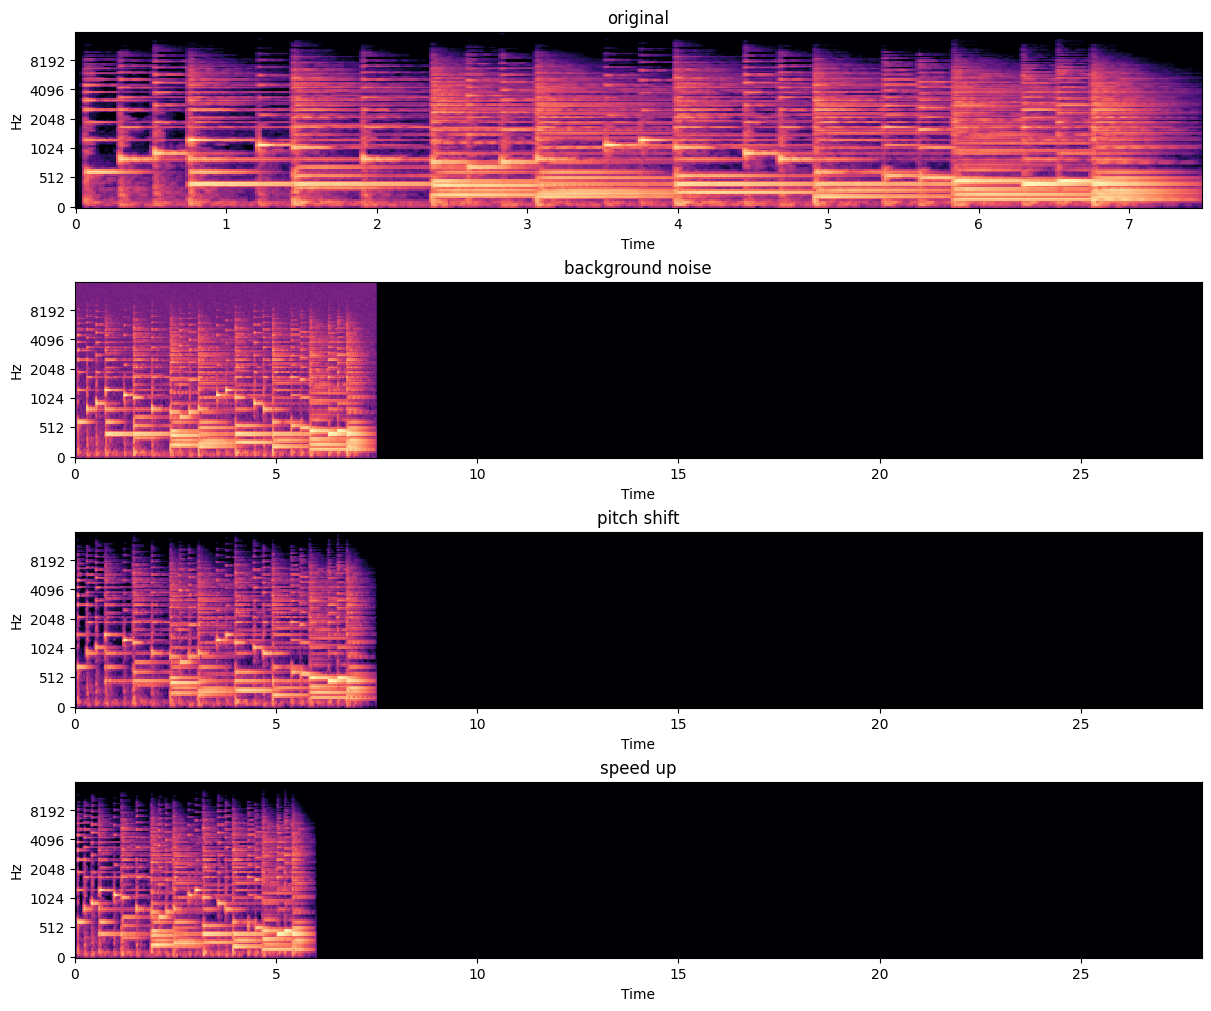

In [5]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), constrained_layout=True)
examples = [
    (audio, "original"),
    (noisy, "background noise"),
    (shifted, "pitch shift"),
    (sped_up, "speed up"),
]

for ax, (signal, title) in zip(axes, examples):
    mel = librosa.feature.melspectrogram(y=signal, sr=sample_rate, n_fft=2048, hop_length=512, n_mels=128)
    mel_db = librosa.power_to_db(mel, ref=1.0)
    librosa.display.specshow(mel_db, sr=sample_rate, hop_length=512, x_axis="time", y_axis="mel", ax=ax, cmap="magma")
    ax.set_title(title)

plt.show()